<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorium 4
## Całkowanie z wykorzystaniem metod Monte Carlo (MC)

---

### Piotr Kitlowski
#### indeks: 303865

In [ ]:
!pip install vegas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import vegas

## Zadanie 3

In [ ]:
def transformed_function(z):
    return np.sin(np.sqrt(z)) * (1 / (2 * np.sqrt(z)))

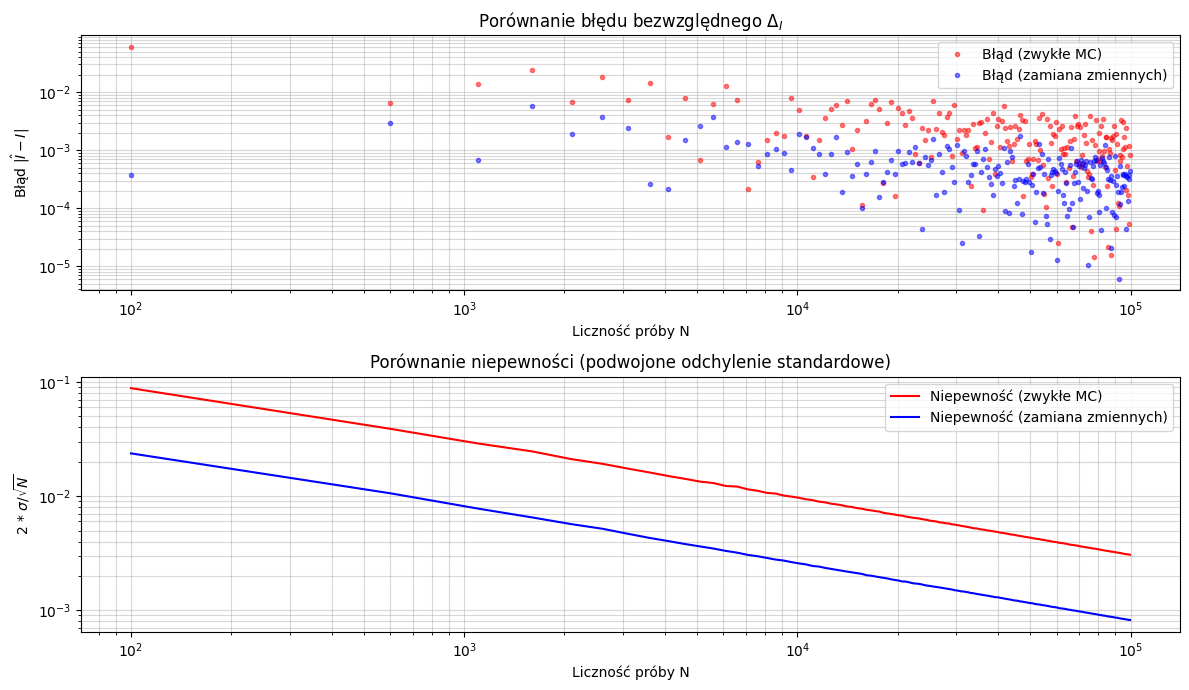

In [ ]:
# 1. Obliczenie analityczne
I_analytical = 1.0

# Zakresy całkowania
x_min, x_max = 0, np.pi / 2
z_min, z_max = 0, (np.pi / 2)**2

N_values = []
n = 100
while n <= 100000:
    N_values.append(n)
    n += 500

results = {
    'direct': {'error': [], 'uncertainty': []},
    'transformed': {'error': [], 'uncertainty': []}
}

for N in N_values:
    # Metoda bezpośrednia
    x_samples = np.random.uniform(x_min, x_max, N)
    f_x = np.sin(x_samples)
    I_hat_direct = (x_max - x_min) * np.mean(f_x)
    std_direct = (x_max - x_min) * np.std(f_x) / np.sqrt(N)

    results['direct']['error'].append(abs(I_hat_direct - I_analytical))
    results['direct']['uncertainty'].append(2 * std_direct)

    # Metoda z zamianą zmiennych
    z_samples = np.random.uniform(z_min, z_max, N)
    f_z = transformed_function(z_samples)
    I_hat_trans = (z_max - z_min) * np.mean(f_z)
    std_trans = (z_max - z_min) * np.std(f_z) / np.sqrt(N)

    results['transformed']['error'].append(abs(I_hat_trans - I_analytical))
    results['transformed']['uncertainty'].append(2 * std_trans)

plt.figure(figsize=(12, 7))

# Błąd bezwzględny - dodano r'...'
plt.subplot(2, 1, 1)
plt.loglog(N_values, results['direct']['error'], 'r.', label='Błąd (zwykłe MC)', alpha=0.5)
plt.loglog(N_values, results['transformed']['error'], 'b.', label='Błąd (zamiana zmiennych)', alpha=0.5)
plt.title(r'Porównanie błędu bezwzględnego $\Delta_I$')
plt.xlabel('Liczność próby N')
plt.ylabel(r'Błąd $| \hat{I} - I |$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

# Niepewność - dodano r'...'
plt.subplot(2, 1, 2)
plt.loglog(N_values, results['direct']['uncertainty'], 'r-', label='Niepewność (zwykłe MC)')
plt.loglog(N_values, results['transformed']['uncertainty'], 'b-', label='Niepewność (zamiana zmiennych)')
plt.title('Porównanie niepewności (podwojone odchylenie standardowe)')
plt.xlabel('Liczność próby N')
plt.ylabel(r'2 * $\sigma / \sqrt{N}$')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

### Podsumowanie Zadania 3: Analiza całki 1D z zamianą zmiennych

Wykresy porównują metodę Monte Carlo bezpośredniego całkowania z metodą wykorzystującą zamianę zmiennych dla całki 1D. Widzimy, że błąd bezwzględny i niepewność (2-krotne odchylenie standardowe) dla obu metod maleją wraz ze wzrostem liczby próbek N.

**Wnioski:**
1.  **Redukcja wariancji:** Metoda z zamianą zmiennych znacząco obniża błąd i niepewność w porównaniu do metody bezpośredniej. Oznacza to znacznie bardziej efektywne obliczanie całki przy tej samej liczbie próbek.
2.  **Efektywność:** Zamiana zmiennych jest szczególnie korzystna, gdy funkcja podcałkowa ma osobliwości, które są wygładzane po transformacji, co prowadzi do szybszej konwergencji do wartości analitycznej.

## Zadanie 6

In [ ]:
# 1. Wartości analityczne
# Integral of (1 + cos(x)) from -pi to pi = [x + sin(x)] from -pi to pi = 2*pi
I_1D_exact = 2 * np.pi
# Dla 3D: (2*pi)^3
I_3D_exact = (2 * np.pi)**3

N_values = np.logspace(2, 6, 10).astype(int) # Od 100 do 1,000,000

# 2. Definicje funkcji podcałkowych
def f1d(x):
    return 1 + np.cos(x[0])

def f3d(x):
    return (1 + np.cos(x[0])) * (1 + np.cos(x[1])) * (1 + np.cos(x[2]))


Obliczanie dla 1D...


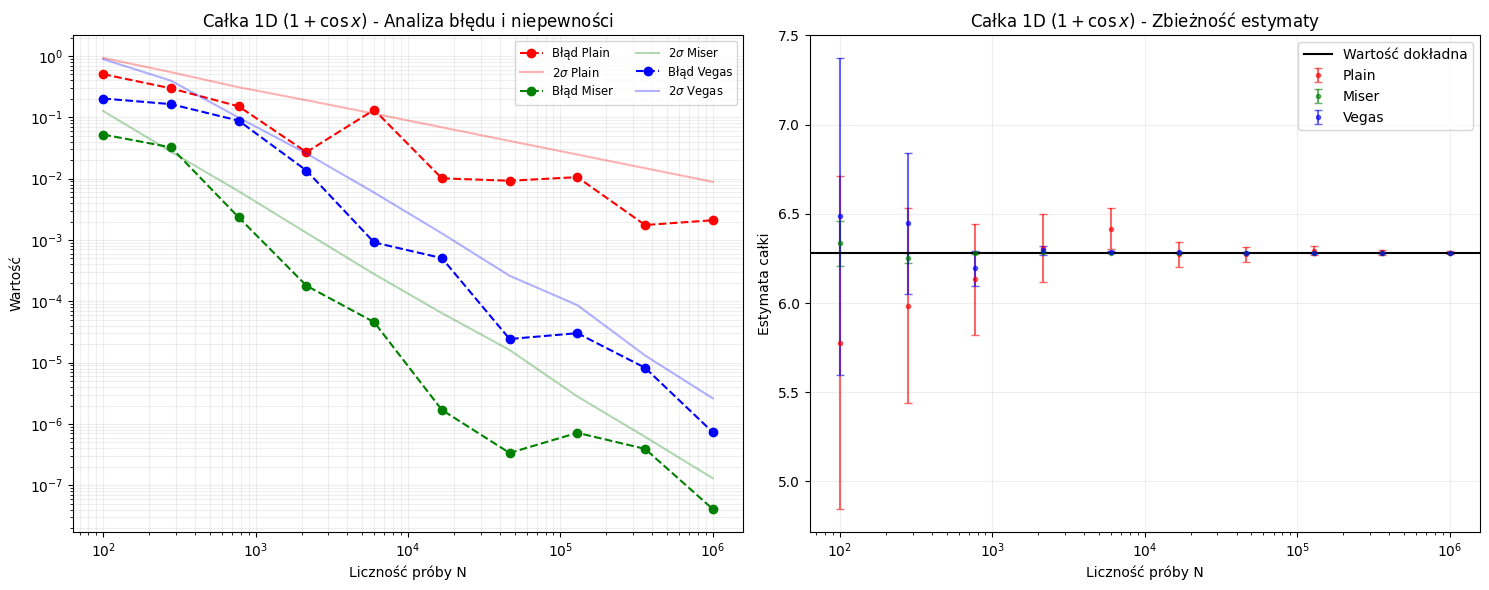

Obliczanie dla 3D...


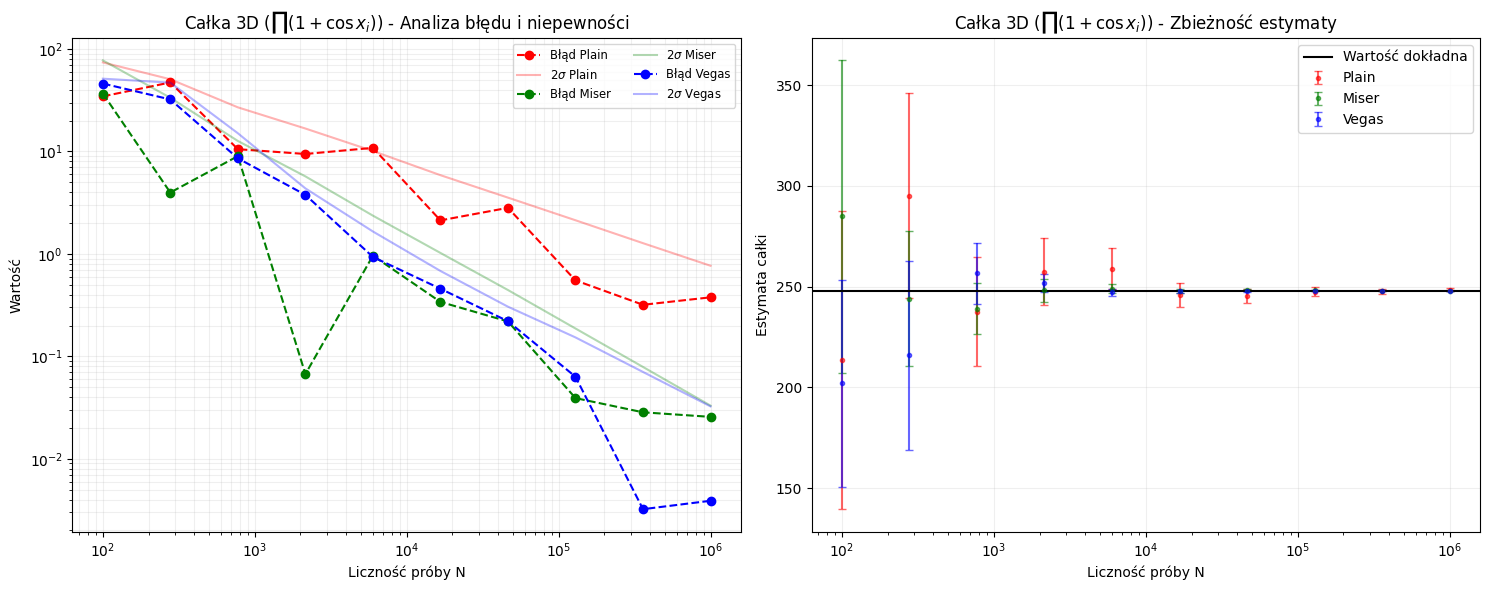

In [ ]:
# --- 2. Silnik symulacji ---
def run_comparison(dim=3):
    # Zakres N zgodnie z potrzebą analizy log-log
    exact = I_3D_exact if dim == 3 else I_1D_exact
    vol = (2 * np.pi)**dim
    region = [[-np.pi, np.pi]] * dim

    results = {
        'Plain': {'err': [], 'unc': [], 'mean': []},
        'Miser': {'err': [], 'unc': [], 'mean': []},
        'Vegas': {'err': [], 'unc': [], 'mean': []}
    }

    for N in N_values:
        # --- PLAIN MC ---
        samples = np.random.uniform(-np.pi, np.pi, (N, dim))
        if dim == 3:
            f_vals = (1 + np.cos(samples[:, 0])) * (1 + np.cos(samples[:, 1])) * (1 + np.cos(samples[:, 2]))
        else:
            f_vals = 1 + np.cos(samples[:, 0])

        I_hat_plain = vol * np.mean(f_vals)
        std_plain = vol * np.std(f_vals) / np.sqrt(N)
        results['Plain']['mean'].append(I_hat_plain)
        results['Plain']['err'].append(abs(I_hat_plain - exact))
        results['Plain']['unc'].append(2 * std_plain)

        # --- MISER (Stratified Sampling) ---
        # W bibliotece vegas stratified=True emuluje zachowanie Miser
        integ_m = vegas.Integrator(region)
        res_m = integ_m(f3d if dim == 3 else f1d, nitn=1, neval=N)
        results['Miser']['mean'].append(res_m.mean)
        results['Miser']['err'].append(abs(res_m.mean - exact))
        results['Miser']['unc'].append(2 * res_m.sdev)

        # --- VEGAS (Importance Sampling) ---
        integ_v = vegas.Integrator(region)
        # Trening (nitn=5) i właściwe całkowanie
        integ_v(f3d if dim == 3 else f1d, nitn=5, neval=N//10)
        res_v = integ_v(f3d if dim == 3 else f1d, nitn=10, neval=N//10)
        results['Vegas']['mean'].append(res_v.mean)
        results['Vegas']['err'].append(abs(res_v.mean - exact))
        results['Vegas']['unc'].append(2 * res_v.sdev)

    return N_values, results

# --- 3. Generowanie wykresów ---
def plot_results(N_vals, res, title, exact_val):
    plt.figure(figsize=(15, 6))
    colors = {'Plain': 'red', 'Miser': 'green', 'Vegas': 'blue'}

    # Wykres lewy: Błąd bezwzględny i Niepewność (LOG-LOG)
    plt.subplot(1, 2, 1)
    for method, data in res.items():
        plt.loglog(N_vals, data['err'], 'o--', color=colors[method], label=f'Błąd {method}')
        plt.loglog(N_vals, data['unc'], '-', color=colors[method], alpha=0.3, label=r'2$\sigma$ ' + method)

    plt.title(f'{title} - Analiza błędu i niepewności')
    plt.xlabel('Liczność próby N')
    plt.ylabel('Wartość')
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True, which="both", alpha=0.2)

    # Wykres prawy: Estymaty z słupkami niepewności
    plt.subplot(1, 2, 2)
    for method, data in res.items():
        plt.errorbar(N_vals, data['mean'], yerr=data['unc'], fmt='.', color=colors[method],
                     capsize=3, label=method, alpha=0.6)

    plt.axhline(y=exact_val, color='black', linestyle='-', linewidth=1.5, label='Wartość dokładna')
    plt.xscale('log')
    plt.title(f'{title} - Zbieżność estymaty')
    plt.xlabel('Liczność próby N')
    plt.ylabel('Estymata całki')
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

# --- 4. Wykonanie obliczeń ---
print("Obliczanie dla 1D...")
N_1d, res_1d = run_comparison(dim=1)
plot_results(N_1d, res_1d, r"Całka 1D ($1 + \cos x$)", I_1D_exact)

print("Obliczanie dla 3D...")
N_3d, res_3d = run_comparison(dim=3)
plot_results(N_3d, res_3d, r"Całka 3D ($\prod (1 + \cos x_i)$)", I_3D_exact)

In [ ]:
def perform_full_analysis():
    # Parametry symulacji zdefiniowane w silniku (N od 100 do 1,000,000)

    # Przypadek A: Całka 1D
    print("Obliczanie dla wymiaru: 1D...")
    N_1d, res_1d = run_comparison(dim=1)

    # Przypadek B: Całka 3D
    print("Obliczanie dla wymiaru: 3D...")
    N_3d, res_3d = run_comparison(dim=3)

    # Definicja kolorów dla spójności
    colors = {'Plain': 'red', 'Miser': 'green', 'Vegas': 'blue'}

    # --- WYKRESY DLA 1D ---
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    for method, data in res_1d.items():
        plt.loglog(N_1d, data['err'], 'o--', color=colors[method], label=f'Błąd {method}')
        plt.loglog(N_1d, data['unc'], '-', color=colors[method], alpha=0.3, label=f'Niepewność 2σ {method}')
    plt.title(r'1D: Błąd i Niepewność ($I_{1D}$)')
    plt.xlabel('N')
    plt.ylabel('Wartość')
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True, which="both", alpha=0.3)

    plt.subplot(1, 2, 2)
    for method, data in res_1d.items():
        plt.errorbar(N_1d, data['mean'], yerr=data['unc'], fmt='o', color=colors[method], capsize=5, label=f'{method}')
    plt.axhline(y=I_1D_exact, color='black', linestyle='--', label='Analityczna')
    plt.xscale('log')
    plt.title(r'1D: Zbieżność estymaty $\hat{I} \pm 2\sigma$')
    plt.xlabel('N')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- WYKRESY DLA 3D ---
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    for method, data in res_3d.items():
        plt.loglog(N_3d, data['err'], 'o--', color=colors[method], label=f'Błąd {method}')
        plt.loglog(N_3d, data['unc'], '-', color=colors[method], alpha=0.3, label=f'Niepewność 2σ {method}')
    plt.title(r'3D: Błąd i Niepewność ($I_{3D}$)')
    plt.xlabel('N')
    plt.ylabel('Wartość')
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True, which="both", alpha=0.3)

    plt.subplot(1, 2, 2)
    for method, data in res_3d.items():
        plt.errorbar(N_3d, data['mean'], yerr=data['unc'], fmt='o', color=colors[method], capsize=5, label=f'{method}')
    plt.axhline(y=I_3D_exact, color='black', linestyle='--', label='Analityczna')
    plt.xscale('log')
    plt.title(r'3D: Zbieżność estymaty $\hat{I} \pm 2\sigma$')
    plt.xlabel('N')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Obliczanie dla wymiaru: 1D...
Obliczanie dla wymiaru: 3D...


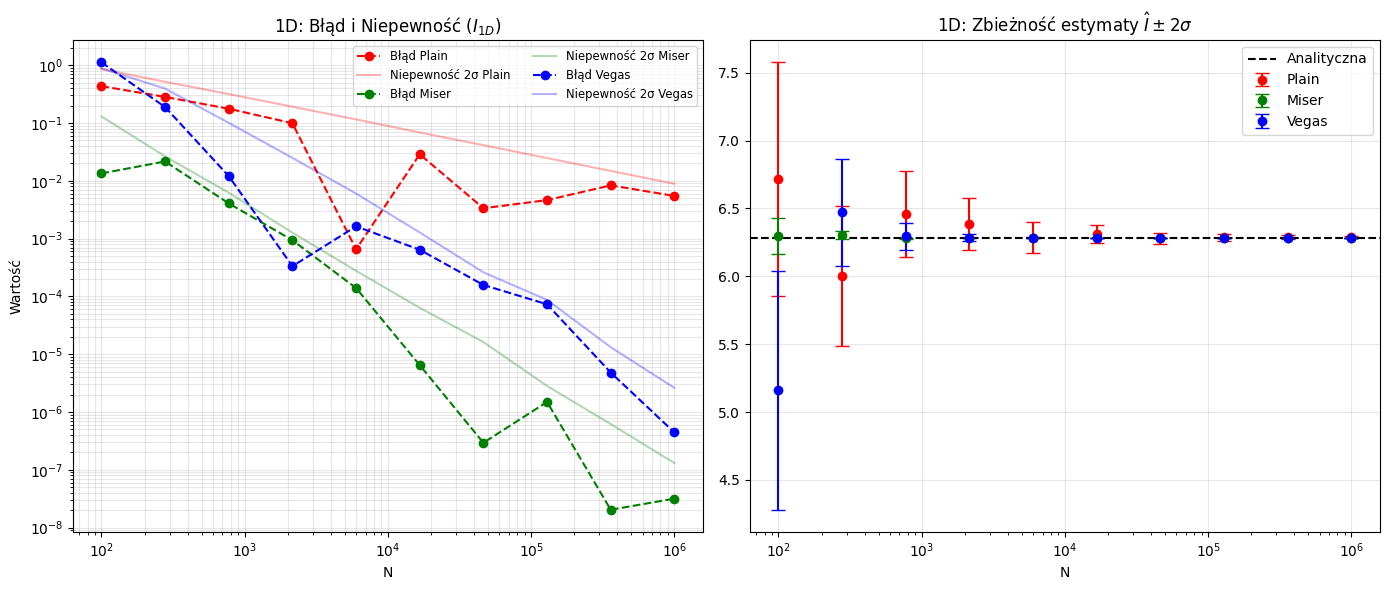

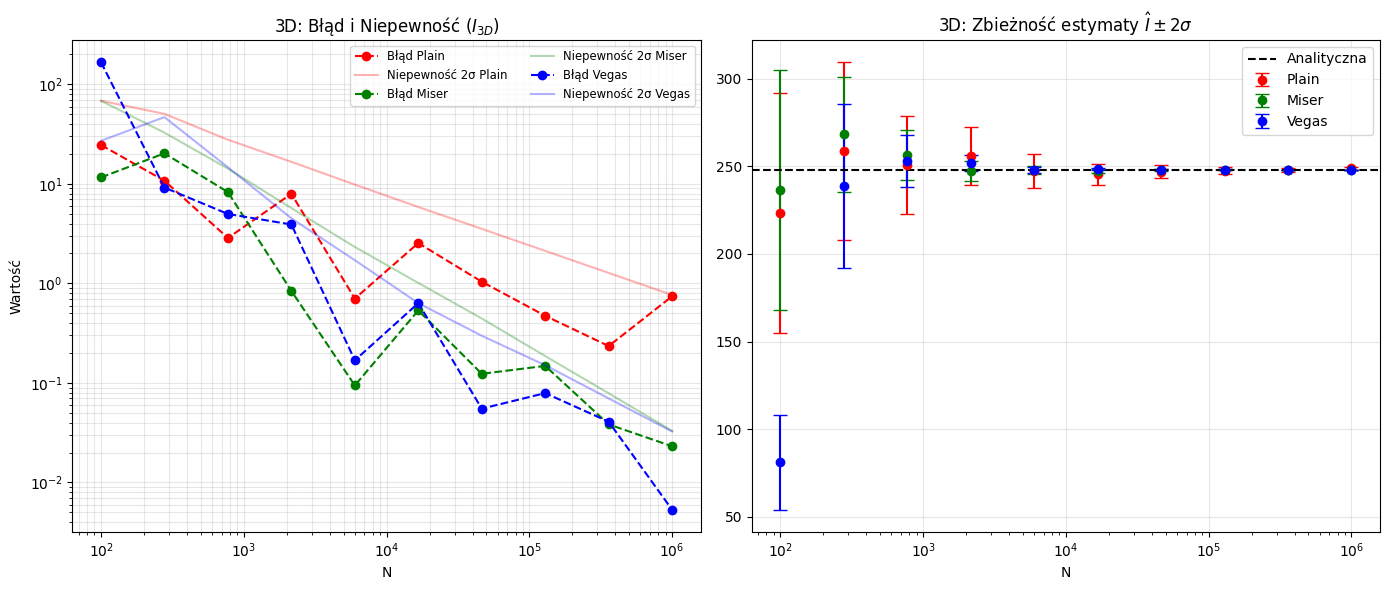

In [ ]:
perform_full_analysis()

### Podsumowanie Zadania 6: Porównanie metod Monte Carlo dla całek 1D i 3D

Analiza porównuje trzy metody Monte Carlo (Plain, Miser, Vegas) dla całek 1D i 3D, oceniając ich błąd, niepewność i zbieżność estymowanych wartości.

**Wnioski:**
1.  **Vegas i Miser vs Plain:** Metody Vegas i Miser oferują znacznie mniejszy błąd i niepewność niż metoda Plain MC, szczególnie dla większej liczby próbek N. Dzieje się tak dzięki zoptymalizowanemu próbkowaniu (Importance Sampling dla Vegas, Stratified Sampling dla Miser).
2.  **Zbieżność:** Estymaty uzyskane metodami Vegas i Miser zbiegają znacznie szybciej do wartości analitycznej, a ich słupki błędów są znacznie mniejsze, co wskazuje na większą precyzję. Jest to szczególnie widoczne w przypadku całki 3D, gdzie złożoność problemu jest większa.